# **Automated Chemical Reactor Simulator**


### **For Isothermal**

--- Advanced Reactor Sizing Tool (Simpson's 1/3 Rule) ---


Enter reaction order (0, 1,2...):  1



Target Conversion: 80.0%
PFR Volume (Simpson's 5-point): 16.2222 L
CSTR Volume: 40.0000 L


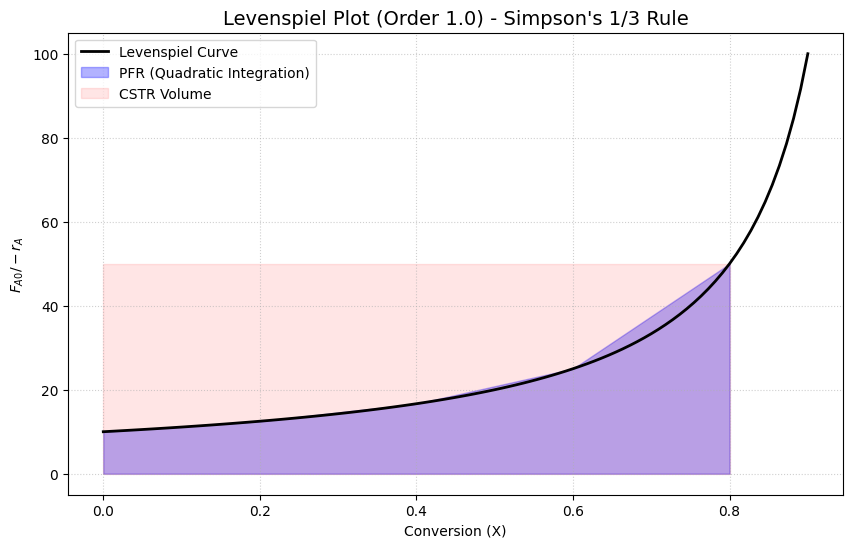

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def reactor_simulator():
    print("--- Advanced Reactor Sizing Tool (Simpson's 1/3 Rule) ---")
    
    # 1. Inputs: Physical Parameters
    k = 0.5       # Rate constant (min^-1)
    Ca0 = 2.0     # Initial concentration (mol/L)
    Fa0 = 10.0    # Molar flow rate (mol/min)
    X_target = 0.8  # Target conversion (80%)
    order = float(input("Enter reaction order (0, 1,2...): "))     # Reaction order

    # 2. Define the Levenspiel Function f(X) = Fa0 / -ra
    # This is the "height" of our graph at any point X
    def f(X):
        # Rate law: -ra = k * Ca0 * (1 - X)^order
        rate = k * (Ca0**order) * ((1 - X)**order)
        return Fa0 / rate

    # 3. IMPLEMENTING SIMPSON'S 1/3 RULE (5-POINT QUADRATIC)
    # We divide the range [0, X_target] into 4 equal strips (5 points)
    n = 4 
    h = X_target / n
    X_points = np.linspace(0, X_target, n + 1)
    Y_points = [f(x) for x in X_points]

    # Simpson's Formula: (h/3) * [f(x0) + 4f(x1) + 2f(x2) + 4f(x3) + f(x4)]
    V_pfr = (h / 3) * (Y_points[0] + 4*Y_points[1] + 2*Y_points[2] + 4*Y_points[3] + Y_points[4])

    # 4. CSTR Volume Calculation (Simple Rectangle)
    V_cstr = f(X_target) * X_target

    print(f"\nTarget Conversion: {X_target*100}%")
    print(f"PFR Volume (Simpson's 5-point): {V_pfr:.4f} L")
    print(f"CSTR Volume: {V_cstr:.4f} L")

    # 5. Visualization
    X_plot = np.linspace(0, 0.9, 100)
    Y_plot = [f(x) for x in X_plot]

    plt.figure(figsize=(10, 6))
    plt.plot(X_plot, Y_plot, 'k-', lw=2, label='Levenspiel Curve')
    
    # Shading the PFR area (Quadratic approximation)
    plt.fill_between(X_points, Y_points, alpha=0.3, color='blue', label='PFR (Quadratic Integration)')
    
    # Drawing the CSTR rectangle
    plt.gca().add_patch(plt.Rectangle((0, 0), X_target, f(X_target), 
                                      alpha=0.1, color='red', label='CSTR Volume'))

    plt.title(f'Levenspiel Plot (Order {order}) - Simpson\'s 1/3 Rule', fontsize=14)
    plt.xlabel('Conversion (X)')
    plt.ylabel('$F_{A0} / -r_A$')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

# Run the simulation
reactor_simulator()


### **For Adiabatic**

Enter reaction order (0, 1,2...):  1


--- Adiabatic Reactor Results (X = 80.0%) ---
PFR Volume: 7.7778 L
CSTR Volume: 13.3333 L


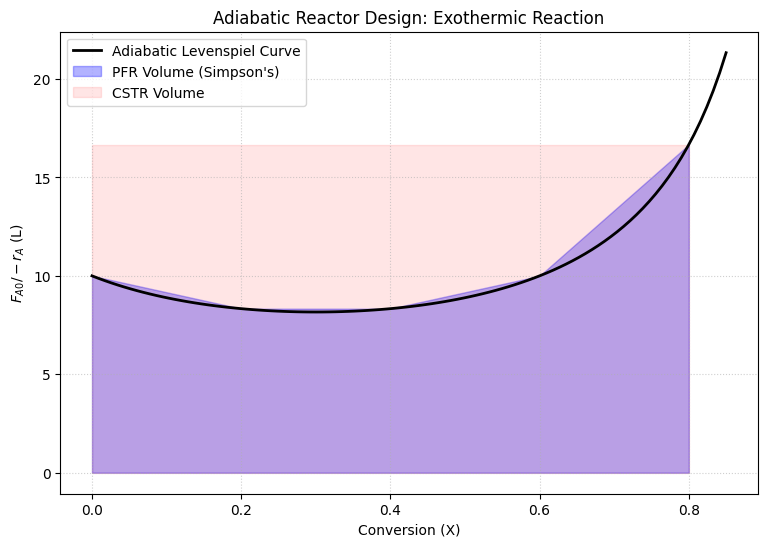

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Reaction Parameters
k_ref = 0.5      # Rate constant at reference temperature (min^-1)
Ca0 = 2.0        # Initial concentration (mol/L)
Fa0 = 10.0       # Molar flow rate (mol/min)
X_target = 0.8   # Target conversion (80%)
order = float(input("Enter reaction order (0, 1,2...): "))     # Reaction order

# 2. Thermal Parameters (Adiabatic)
delta_H = -50000 # Heat of reaction (J/mol) - Exothermic
Cp = 200         # Heat capacity of the mixture (J/mol*K)

# 3. The Adiabatic Design Function
def f_adiabatic(X):
    """
    Calculates Fa0/-ra while accounting for adiabatic temperature rise.
    As conversion (X) increases, Temperature (T) increases, which increases k.
    """
    # Adiabatic Temperature Rise: T = T0 + (-delta_H * X) / Cp
    # We model the increase in k as a function of the temperature rise
    k_eff = k_ref * (1 + (abs(delta_H) * X / (Cp * 100))) 
    
    rate = k_eff * (Ca0**order) * ((1 - X)**order)
    return Fa0 / rate

# --- PFR VOLUME: Simpson's 1/3 Rule (5-Point) ---
h = X_target / 4
X_pts = np.linspace(0, X_target, 5)
Y_pts = [f_adiabatic(x) for x in X_pts]

# Formula: (h/3) * [f0 + 4f1 + 2f2 + 4f3 + f4]
V_pfr = (h/3) * (Y_pts[0] + 4*Y_pts[1] + 2*Y_pts[2] + 4*Y_pts[3] + Y_pts[4])

# --- CSTR VOLUME: Single Stage ---
V_cstr = f_adiabatic(X_target) * X_target

# 4. Results & Visualization
print(f"--- Adiabatic Reactor Results (X = {X_target*100}%) ---")
print(f"PFR Volume: {V_pfr:.4f} L")
print(f"CSTR Volume: {V_cstr:.4f} L")

# Plotting the Levenspiel Curve
X_curve = np.linspace(0, 0.85, 100)
Y_curve = [f_adiabatic(x) for x in X_curve]

plt.figure(figsize=(9, 6))
plt.plot(X_curve, Y_curve, 'k-', lw=2, label="Adiabatic Levenspiel Curve")
plt.fill_between(X_pts, Y_pts, color='blue', alpha=0.3, label="PFR Volume (Simpson's)")
plt.gca().add_patch(plt.Rectangle((0, 0), X_target, f_adiabatic(X_target), 
                                  color='red', alpha=0.1, label="CSTR Volume"))

plt.title("Adiabatic Reactor Design: Exothermic Reaction")
plt.xlabel("Conversion (X)")
plt.ylabel("$F_{A0} / -r_A$ (L)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()